In [1]:
# Copyright (c) Meta Platforms, Inc. and affiliates.

## Image segmentation with SAM 3

This notebook demonstrates how to use SAM 3 for image segmentation with text or visual prompts. It covers the following capabilities:

- **Text prompts**: Using natural language descriptions to segment objects (e.g., "person", "face")
- **Box prompts**: Using bounding boxes as exemplar visual prompts

# <a target="_blank" href="https://colab.research.google.com/github/facebookresearch/sam3/blob/main/notebooks/sam3_image_predictor_example.ipynb">
#   <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
# </a>

In [2]:
using_colab = False

In [3]:
if using_colab:
    import torch
    import torchvision
    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    import sys
    !{sys.executable} -m pip install opencv-python matplotlib scikit-learn
    !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/sam3.git'

In [4]:
import os

import matplotlib.pyplot as plt
import numpy as np

import sam3
from PIL import Image
from sam3 import build_sam3_image_model
from sam3.model.box_ops import box_xywh_to_cxcywh
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results, plot_bbox

sam3_root = os.path.join(os.path.dirname(sam3.__file__), "..")

/shares/feldmann.ics.mnf.uzh/Yuqi/sam3/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [5]:
import torch

# turn on tfloat32 for Ampere GPUs
# https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# use bfloat16 for the entire notebook
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

<!-- # Build Model -->

In [6]:
# Build model and load fine-tuned checkpoint
my_checkpoint_path = "/home/yuqyan/Yuqi/sam3/scratch/sam3_finetuning_2026-02-24_19-04-51/checkpoints/checkpoint.pt"

bpe_path = f"{sam3_root}/sam3/assets/bpe_simple_vocab_16e6.txt.gz"

# Build model (will load default HF checkpoint first)
model = build_sam3_image_model(bpe_path=bpe_path)

# Load fine-tuned checkpoint if it exists
if os.path.exists(my_checkpoint_path):
    print(f"Loading fine-tuned checkpoint from: {my_checkpoint_path}")
    checkpoint = torch.load(my_checkpoint_path, map_location="cpu")
    
    # Extract model state dict
    if "model" in checkpoint:
        state_dict = checkpoint["model"]
    elif "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
    else:
        state_dict = checkpoint
    
    # Remove DDP prefix if present
    new_state_dict = {}
    for k, v in state_dict.items():
        if k.startswith("module."):
            new_state_dict[k[7:]] = v
        else:
            new_state_dict[k] = v
    
    # Load checkpoint
    try:
        msg = model.load_state_dict(new_state_dict, strict=False)
        print(f"✅ Loaded checkpoint: {msg}")
    except Exception as e:
        print(f"⚠️ Error loading checkpoint: {e}")
        raise
else:
    print(f"⚠️ Checkpoint not found: {my_checkpoint_path}")
    print("Using default HuggingFace checkpoint.")

loaded /home/yuqyan/.cache/huggingface/hub/models--facebook--sam3/snapshots/3c879f39826c281e95690f02c7821c4de09afae7/sam3.pt and found missing and/or unexpected keys:
missing_keys=[]
unexpected_keys=['backbone.vision_backbone.sam2_convs.0.dconv_2x2_0.weight', 'backbone.vision_backbone.sam2_convs.0.dconv_2x2_0.bias', 'backbone.vision_backbone.sam2_convs.0.dconv_2x2_1.weight', 'backbone.vision_backbone.sam2_convs.0.dconv_2x2_1.bias', 'backbone.vision_backbone.sam2_convs.0.conv_1x1.weight', 'backbone.vision_backbone.sam2_convs.0.conv_1x1.bias', 'backbone.vision_backbone.sam2_convs.0.conv_3x3.weight', 'backbone.vision_backbone.sam2_convs.0.conv_3x3.bias', 'backbone.vision_backbone.sam2_convs.1.dconv_2x2.weight', 'backbone.vision_backbone.sam2_convs.1.dconv_2x2.bias', 'backbone.vision_backbone.sam2_convs.1.conv_1x1.weight', 'backbone.vision_backbone.sam2_convs.1.conv_1x1.bias', 'backbone.vision_backbone.sam2_convs.1.conv_3x3.weight', 'backbone.vision_backbone.sam2_convs.1.conv_3x3.bias', 'b

In [ ]:
image_path = "/home/yuqyan/Yuqi/LSB-AI-Detection/data/02_processed/renders/current/linear_magnitude/00011_eo/0000.png"
image = Image.open(image_path)
width, height = image.size
processor = Sam3Processor(model, confidence_threshold=0.30)
inference_state = processor.set_image(image)


# Text prompt

Raw score max (pre-threshold): 0.855469 | threshold: 0.001000 | min: 0.000519 | mean: 0.171875
found 198 object(s)


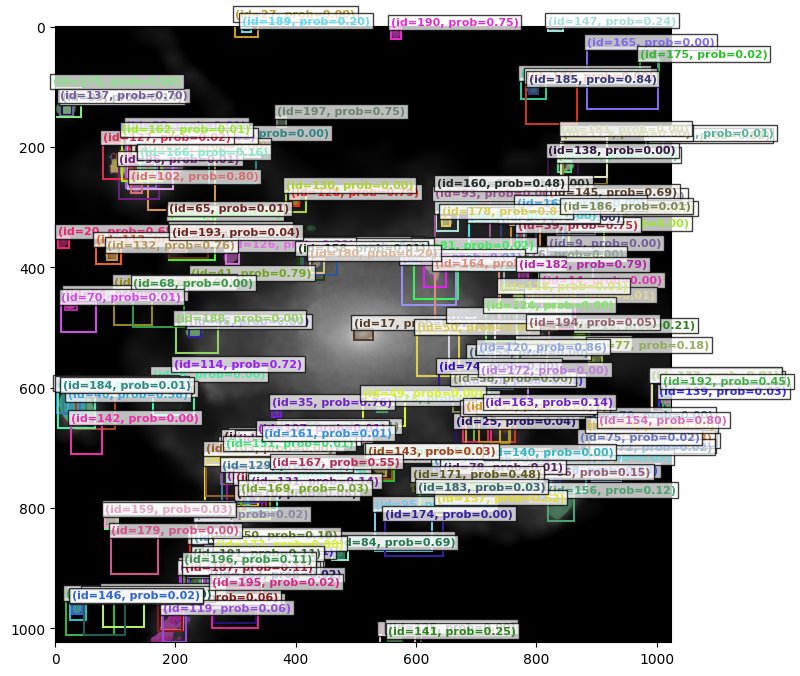

In [9]:
processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="satellite galaxy")

with torch.inference_mode():
    raw_outputs = model.forward_grounding(
        backbone_out=inference_state["backbone_out"],
        find_input=processor.find_stage,
        geometric_prompt=inference_state.get("geometric_prompt", model._get_dummy_prompt()),
        find_target=None,
    )
    raw_probs = raw_outputs["pred_logits"].sigmoid()
    presence = raw_outputs["presence_logit_dec"].sigmoid().unsqueeze(1)
    raw_probs = (raw_probs * presence).squeeze(-1)
    print(
        f"Raw score max (pre-threshold): {raw_probs.max().item():.6f} | "
        f"threshold: {processor.confidence_threshold:.6f} | "
        f"min: {raw_probs.min().item():.6f} | mean: {raw_probs.mean().item():.6f}"
    )

img0 = Image.open(image_path)
plot_results(img0, inference_state)


dict_keys(['original_height', 'original_width', 'backbone_out', 'geometric_prompt', 'masks_logits', 'masks', 'boxes', 'scores'])
mask[0]: dtype=torch.bool, shape=torch.Size([1024, 1024]), unique=[False, True], score=0.4551
mask[1]: dtype=torch.bool, shape=torch.Size([1024, 1024]), unique=[False, True], score=0.4512
mask[2]: dtype=torch.bool, shape=torch.Size([1024, 1024]), unique=[False, True], score=0.3125
mask[3]: dtype=torch.bool, shape=torch.Size([1024, 1024]), unique=[False, True], score=0.5977
mask[4]: dtype=torch.bool, shape=torch.Size([1024, 1024]), unique=[False, True], score=0.6836
mask[5]: dtype=torch.bool, shape=torch.Size([1024, 1024]), unique=[False, True], score=0.3926
mask[6]: dtype=torch.bool, shape=torch.Size([1024, 1024]), unique=[False, True], score=0.5078
mask[7]: dtype=torch.bool, shape=torch.Size([1024, 1024]), unique=[False, True], score=0.5156
mask[8]: dtype=torch.bool, shape=torch.Size([1024, 1024]), unique=[False, True], score=0.4824
mask[9]: dtype=torch.bool

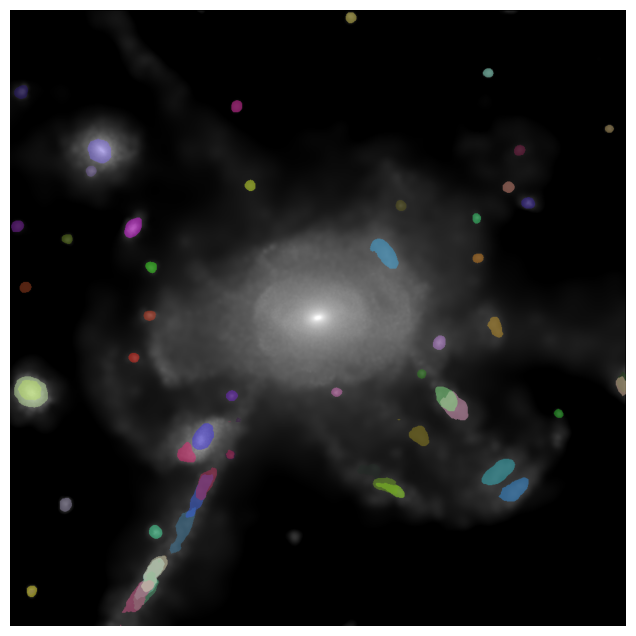

In [12]:
processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="could you show all satellits")

print(inference_state.keys())
# -> dict_keys(['original_height', 'original_width', 'backbone_out',
#               'geometric_prompt', 'masks_logits', 'masks', 'boxes', 'scores'])

for i, m in enumerate(inference_state["masks"]):
    mask_np = m.squeeze(0).cpu()
    print(f"mask[{i}]: dtype={mask_np.dtype}, shape={mask_np.shape}, "
          f"unique={mask_np.unique().tolist()}, score={inference_state['scores'][i].item():.4f}")

import matplotlib.pyplot as plt
from sam3.visualization_utils import plot_mask, COLORS

plt.figure(figsize=(12, 8))
plt.imshow(Image.open(image_path))
for i in range(len(inference_state["scores"])):
    plot_mask(inference_state["masks"][i].squeeze(0).cpu(), color=COLORS[i % len(COLORS)])
plt.axis("off")
plt.show()


In [ ]:
inference_state.keys()
inference_state["masks_logits"]

tensor([0.0000e+00, 2.9389e-39, 2.9396e-39,  ..., 1.0000e+00, 1.0000e+00,
        1.0000e+00], device='cuda:0')

### Visual prompt: a single bounding box

Normalized box input: [0.732421875, 0.439453125, 0.09765625, 0.09765625]


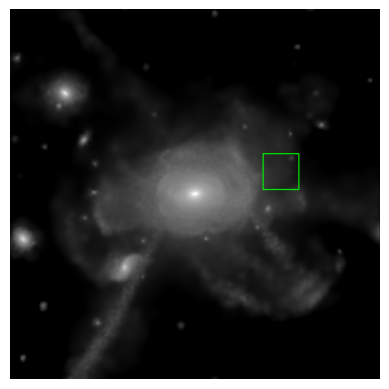

In [10]:
# Here the box is in  (x,y,w,h) format, where (x,y) is the top left corner.
box_input_xywh = torch.tensor([700.0, 400.0, 100, 100.0]).view(-1, 4)
box_input_cxcywh = box_xywh_to_cxcywh(box_input_xywh)

norm_box_cxcywh = normalize_bbox(box_input_cxcywh, width, height).flatten().tolist()
print("Normalized box input:", norm_box_cxcywh)

processor.reset_all_prompts(inference_state)
inference_state = processor.add_geometric_prompt(
    state=inference_state, box=norm_box_cxcywh, label=True
)

img0 = Image.open(image_path)
image_with_box = draw_box_on_image(img0, box_input_xywh.flatten().tolist())
plt.imshow(image_with_box)
plt.axis("off")  # Hide the axis
plt.show()

found 200 object(s)


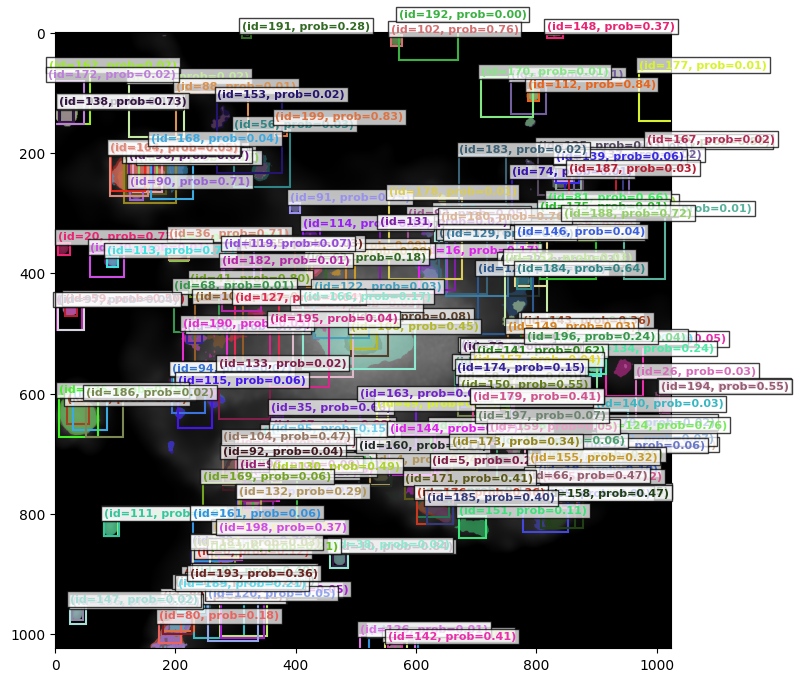

In [11]:
plot_results(img0, inference_state)

### Visual prompt: multi-box prompting (with positive and negative boxes)

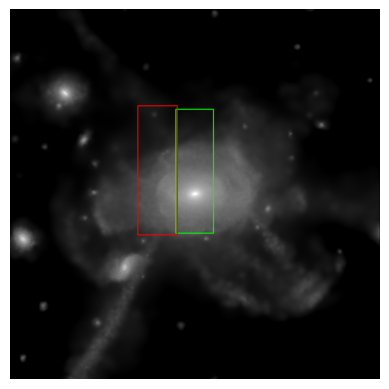

In [23]:
box_input_xywh = [[480.0, 290.0, 110.0, 360.0], [370.0, 280.0, 115.0, 375.0]]
box_input_cxcywh = box_xywh_to_cxcywh(torch.tensor(box_input_xywh).view(-1,4))
norm_boxes_cxcywh = normalize_bbox(box_input_cxcywh, width, height).tolist()

box_labels = [True, False]

processor.reset_all_prompts(inference_state)

for box, label in zip(norm_boxes_cxcywh, box_labels):
    inference_state = processor.add_geometric_prompt(
        state=inference_state, box=box, label=label
    )

img0 = Image.open(image_path)
image_with_box = img0
for i in range(len(box_input_xywh)):
    if box_labels[i] == 1:
        color = (0, 255, 0)
    else:
        color = (255, 0, 0)
    image_with_box = draw_box_on_image(image_with_box, box_input_xywh[i], color)
plt.imshow(image_with_box)
plt.axis("off")  # Hide the axis
plt.show()

found 1 object(s)


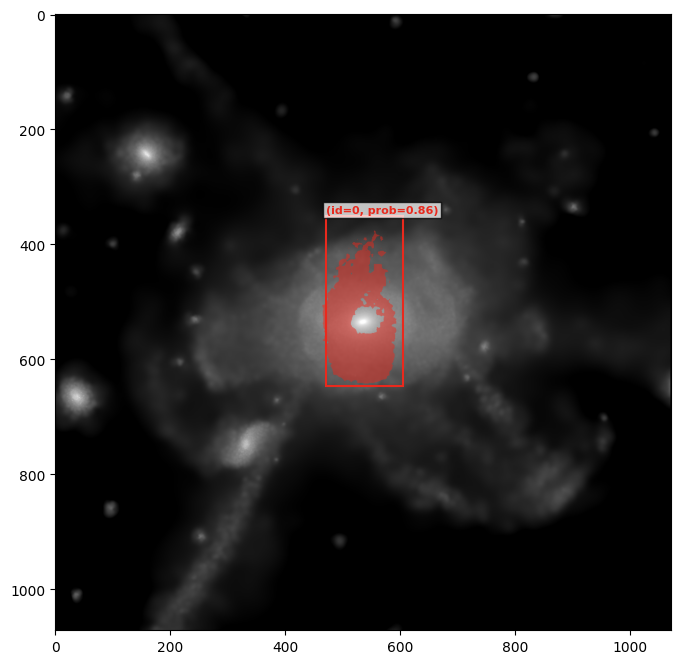

In [24]:
plot_results(img0, inference_state)